# Scaling and RAM: how far does each tool go?

The headline here is **how wall time and memory grow with the number of
queries**, and prot2exon is plotted head to head against the other
protein-to-genome tools. The others top out between 1,000 and 10,000 queries
(beyond that they extrapolate to hours), while prot2exon runs all the way to
1,000,000. The second half of the notebook covers two things only prot2exon
offers, so there is nothing to line them up against: OpenMP `--threads` and the
`--batch-size` RAM cap.

It visualises the raw outputs from `benchmarks/scaling_benchmark.py` and
`benchmarks/parallel_benchmark.py`. Same numbers as the wiki's
[Speed and memory usage](https://github.com/SotoLF/Prot2Exon/wiki/Performance-and-Benchmarking#speed-and-memory-usage) and
[Speed vs other tools](https://github.com/SotoLF/Prot2Exon/wiki/Performance-and-Benchmarking#speed-vs-other-tools) sections, with the plots beside them
so you can sanity-check the claim before quoting it.

## Setup

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import pandas as pd
from pathlib import Path

DATA = Path.home() / "Desktop" / "protein2genomic_data"
TIMINGS = DATA / "bench" / "timings.tsv"
# Combined threads x batch-size grid (benchmarks/threads_batch_grid.py).
GRID = DATA / "bench" / "threads_batch_grid.tsv"

assert TIMINGS.exists(), f"missing {TIMINGS} (run benchmarks/scaling_benchmark.py)"
assert GRID.exists(),    f"missing {GRID} (run benchmarks/threads_batch_grid.py)"
print(f"timings : {TIMINGS}")
print(f"grid    : {GRID}")

timings : /home/goguxor/Desktop/protein2genomic_data/bench/timings.tsv
grid    : /home/goguxor/Desktop/protein2genomic_data/bench/threads_batch_grid.tsv


## 1. Wall time and memory vs N, head to head

Single thread, both tools measured from N = 100. prot2exon's curve runs to
1,000,000 queries; ensembldb caps at 10,000 (beyond that the wall time is
impractical). The gap widens with N because prot2exon's per-query cost is
microseconds once the index is loaded. (The other tools were only run at a single
N — they're in the cross-tool comparison in `software_comparison.ipynb`, not on
this scaling axis.)

In [2]:
t = pd.read_csv(TIMINGS, sep="\t")
# Median across reps per (tool, n).
agg = (t.groupby(["tool", "n"], as_index=False)
        .agg(wall_s=("wall_s", "median"),
             peak_rss_mb=("peak_rss_mb", "median")))
agg.pivot(index="n", columns="tool", values="wall_s")

tool,ensembldb,prot2exon
n,,
100,23.319,1.3245
1000,168.835,1.3650
10000,1558.198,1.7100
100000,NaN,4.6570
1000000,NaN,129.3525


/tmp/ipykernel_545909/2250722686.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[0].plot(sub["n"], sub["wall_s"], "o-", label=tool, color=color, **style)
/tmp/ipykernel_545909/2250722686.py:14: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1].plot(sub["n"], sub["peak_rss_mb"], "o-", label=tool, color=color, **style)
/tmp/ipykernel_545909/2250722686.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


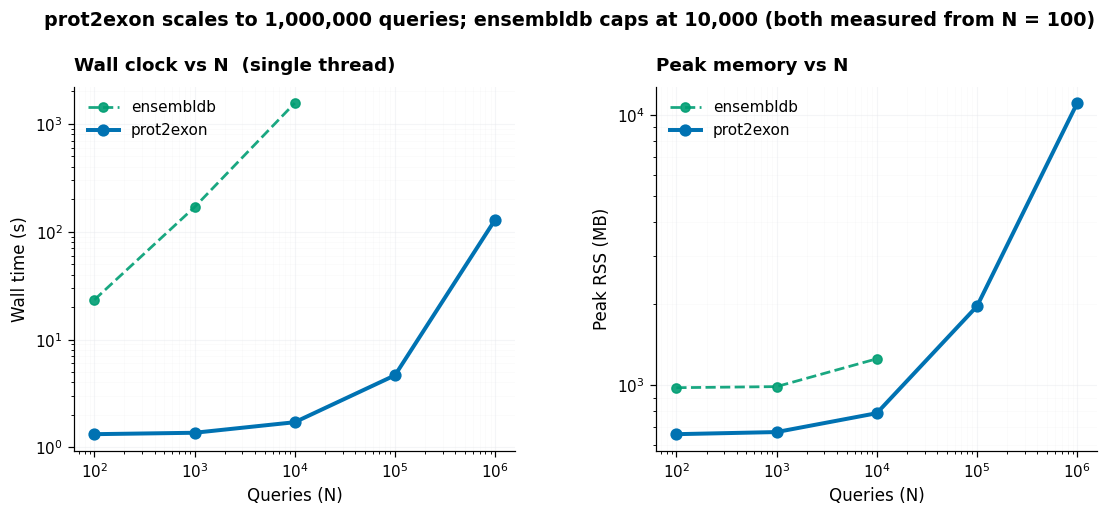

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3),
                         gridspec_kw={'wspace': 0.32})
tool_palette = {'prot2exon': COLORS['prot2exon'], 'ensembldb': COLORS['ensembldb']}

# Two tools with a real scaling curve, both measured from N = 100: prot2exon (to
# 1M) and ensembldb (to 10K). The other tools are single-N points — they belong
# in the cross-tool bar chart (software_comparison), not on a scaling axis.
for tool, sub in agg.groupby("tool"):
    sub = sub.sort_values("n")
    color = tool_palette.get(tool, COLORS['neutral'])
    style = {'lw': 2.6, 'markersize': 7} if tool == 'prot2exon' \
        else {'lw': 1.8, 'markersize': 6, 'linestyle': '--', 'alpha': 0.9}
    axes[0].plot(sub["n"], sub["wall_s"], "o-", label=tool, color=color, **style)
    axes[1].plot(sub["n"], sub["peak_rss_mb"], "o-", label=tool, color=color, **style)

for ax in axes:
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Queries (N)")
    ax.grid(which='major', alpha=0.4, lw=0.7); ax.grid(which='minor', alpha=0.2, lw=0.5)
axes[0].set_ylabel("Wall time (s)")
axes[0].set_title("Wall clock vs N  (single thread)", loc='left')
axes[1].set_ylabel("Peak RSS (MB)")
axes[1].set_title("Peak memory vs N", loc='left')
axes[0].legend(loc='upper left', framealpha=0.9)
axes[1].legend(loc='upper left', framealpha=0.9)

fig.suptitle("prot2exon scales to 1,000,000 queries; ensembldb caps at 10,000 "
             "(both measured from N = 100)",
             fontsize=12.5, fontweight='semibold', y=1.04)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [4]:
# The ~1.3 s floor at low N is one-time index load (~298 MB binary
# index). Per-query mapping is essentially free until we get to 100k+.
small = agg.query("tool == 'prot2exon' and n <= 10000")
print("prot2exon wall (s):", dict(zip(small['n'], small['wall_s'].round(2))))

prot2exon wall (s): {100: 1.32, 1000: 1.36, 10000: 1.71}


## 2. Parallelism × memory: `--threads` and `--batch-size` together

Two independent knobs, so we sweep them as one grid rather than in two separate
plots: **`--threads`** trades wall time (OpenMP-parallel per-query mapping),
**`--batch-size`** trades peak RAM (streams results to disk in chunks of N and
frees each chunk; `0`/omitted = one-shot, **byte-identical** output either way).
Read it as: wall time falls *down* each column, peak RAM falls *across* each row.

In [5]:
g = pd.read_csv(GRID, sep="\t")
g["peak_rss_gb"] = g["peak_rss_mb"] / 1024
# wall (s) and peak RAM (GB) as two compact grids
print("wall time (s):")
print(g.pivot_table(index="threads", columns="batch_label", values="wall_s").round(1))
print("\npeak RSS (GB):")
print(g.pivot_table(index="threads", columns="batch_label", values="peak_rss_gb").round(1))

wall time (s):
batch_label  10,000  100,000  50,000  one-shot
threads                                       
1              19.0     18.7    18.4      22.9
2              15.1     15.4    15.1      15.6
4              13.1     13.2    13.2      12.6
8              12.3     12.2    12.3      11.2
16             12.0     12.1    12.0      10.8

peak RSS (GB):
batch_label  10,000  100,000  50,000  one-shot
threads                                       
1               0.9      2.3     1.5      13.3
2               0.9      2.3     1.6      13.3
4               0.9      2.3     1.5      13.3
8               0.9      2.3     1.6      13.3
16              1.0      2.5     1.7      13.3


/tmp/ipykernel_545909/4092733981.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


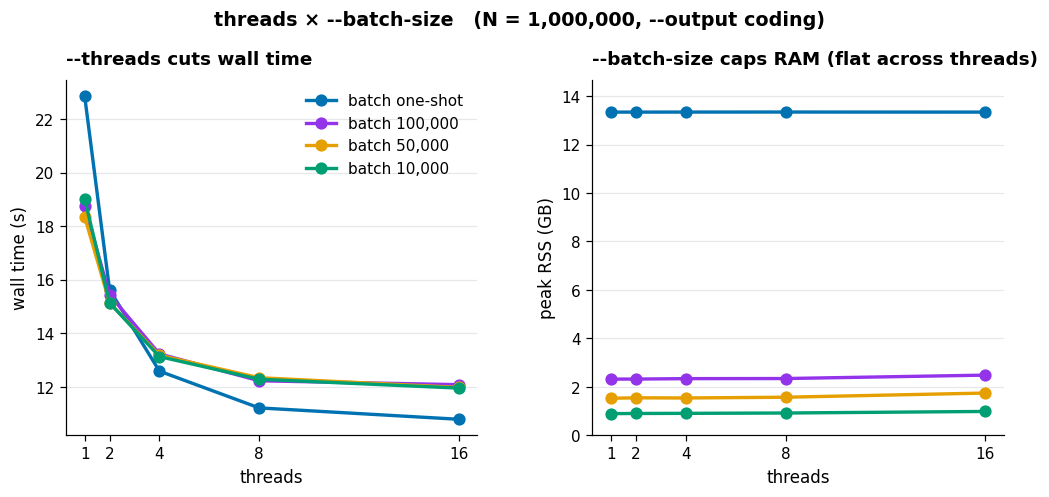

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2),
                       gridspec_kw={'wspace': 0.28})
# colour by batch size; show whichever batch labels are present
palette = [COLORS['prot2exon'], '#9333ea', COLORS['transvar'], COLORS['good']]
order = [b for b in ["one-shot", "100,000", "50,000", "10,000"]
         if b in set(g.batch_label)]
cmap = {lab: palette[i] for i, lab in enumerate(order)}
xt = sorted(g.threads.unique())
for lab in order:
    s = g[g.batch_label == lab].sort_values("threads")
    ax[0].plot(s.threads, s.wall_s, "o-", color=cmap[lab], lw=2.2,
               markersize=7, label=f"batch {lab}")
    ax[1].plot(s.threads, s.peak_rss_gb, "o-", color=cmap[lab], lw=2.2,
               markersize=7, label=f"batch {lab}")
ax[0].set_xlabel("threads"); ax[0].set_ylabel("wall time (s)")
ax[0].set_title("--threads cuts wall time", loc="left")
ax[0].set_xticks(xt); ax[0].legend()
ax[1].set_xlabel("threads"); ax[1].set_ylabel("peak RSS (GB)")
ax[1].set_title("--batch-size caps RAM (flat across threads)", loc="left")
ax[1].set_xticks(xt); ax[1].set_ylim(0, g.peak_rss_gb.max() * 1.1)
fig.suptitle(f"threads × --batch-size   (N = 1,000,000, --output coding)",
             fontsize=12.5, fontweight='semibold', y=1.03)
fig.tight_layout()
plt.show()

## What this tells you

(Grid measured on a quiet 32-core / 125 GB workstation at N = 1,000,000, so
nothing swaps — this is the pure compute/memory tradeoff.)

- **`--threads` cuts wall time ~2.1×** by 16 threads (22.9 → 10.8 s one-shot;
  ~1.5× already at 2 threads), then plateaus as the single-threaded TSV writer
  and memory bandwidth take over. Set `--threads` to your physical core count.
- **`--batch-size` caps peak RAM, independent of thread count** — one-shot holds
  ~13 GB, `--batch-size 100000 / 50000 / 10000` = ~2.4 / 1.6 / 0.9 GB,
  byte-identical output. The two knobs are orthogonal: threads for time, batch
  for memory.
- **Across a row, bigger batches are slightly faster** (fewer flush cycles,
  approaching one-shot) but use proportionally more RAM — a genuine speed/memory
  dial. The exception is **single-threaded**, where one-shot is the *slowest*
  cell because the 13 GB working set thrashes the allocator; any batch fixes it.
- **Rule of thumb:** one-shot is fastest with spare cores *and* RAM; otherwise
  `--batch-size 10000` gives ~14× less memory for ~10–15 % more wall. Batch when
  N is large or RAM is tight.
- **Scaling stays linear in N once the index is loaded** (section 1): the ~1.3 s
  floor at small N is the one-time index load.